In [44]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('kc-house-data (1)(1).csv',sep=',', encoding='latin-1')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [32]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [33]:
df.describe()
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


1.2. Изучите стоимости недвижимости

In [4]:
df.describe(include='object')

,date
count,21613
unique,372
top,20140623T000000
freq,142


In [2]:
df['price'].max()

7700000.0

In [3]:
df['price'].min()

75000.0

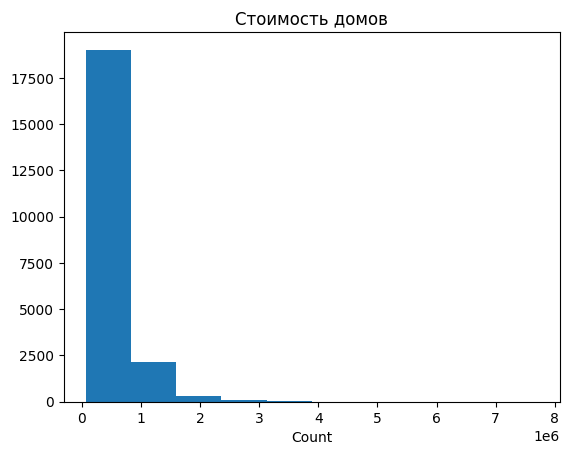

In [7]:
plt.hist(df['price']);
plt.xlabel('$')
plt.xlabel('Count')
plt.title('Стоимость домов');

In [8]:
df['price'].value_counts()

price
350000.0     172
450000.0     172
550000.0     159
500000.0     152
425000.0     150
            ... 
607010.0       1
1362500.0      1
298800.0       1
957500.0       1
402101.0       1
Name: count, Length: 4028, dtype: int64

In [9]:
data=df['price'].value_counts()
data

price
350000.0     172
450000.0     172
550000.0     159
500000.0     152
425000.0     150
            ... 
607010.0       1
1362500.0      1
298800.0       1
957500.0       1
402101.0       1
Name: count, Length: 4028, dtype: int64

In [97]:
df.groupby('price').agg({'sqft_living': 'mean'})

,sqft_living
price,
75000.0,670.0
78000.0,780.0
80000.0,430.0
81000.0,730.0
82000.0,860.0
...,...
5350000.0,8000.0
5570000.0,9200.0
6885000.0,9890.0


In [98]:
data1=df.groupby('floors').agg({'price': 'mean'}).sort_values('price')
data1

,price
floors,
1.0,4.421806e+05
1.5,5.589806e+05
3.0,5.825260e+05
2.0,6.488912e+05
3.5,9.333125e+05
2.5,1.060346e+06


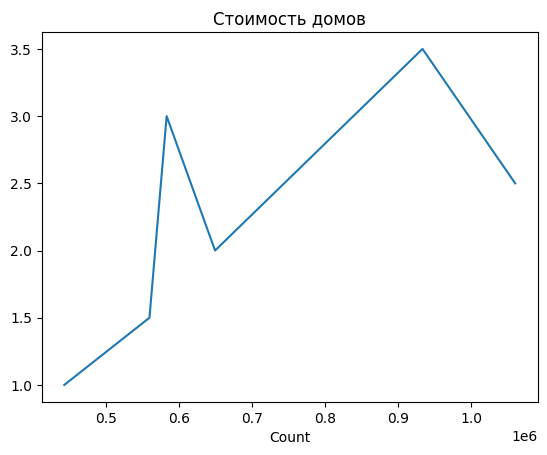

In [99]:

plt.plot(data1.values, data1.index);
plt.xlabel('$')
plt.xlabel('Count')
plt.title('Стоимость домов');

In [90]:
df.groupby('sqft_living').agg({'price': ['min', 'mean', 'max']})

price                      
                   min       mean        max
sqft_living                                 
290           142000.0   142000.0   142000.0
370           276000.0   276000.0   276000.0
380           245000.0   245000.0   245000.0
384           265000.0   265000.0   265000.0
390           228000.0   236500.0   245000.0
...                ...        ...        ...
9640         4668000.0  4668000.0  4668000.0
9890         6885000.0  6885000.0  6885000.0
10040        7062500.0  7062500.0  7062500.0
12050        7700000.0  7700000.0  7700000.0
13540        2280000.0  2280000.0  2280000.0

[1038 rows x 3 columns]

In [102]:
df.pivot_table(index='price', columns='sqft_living',aggfunc='mean',values='floors')

sqft_living,290,370,380,384,390,410,420,430,440,460,...,8000,8010,8020,8670,9200,9640,9890,10040,12050,13540
price,,,,,,,,,,,,,,,,,,,,,
75000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5350000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5570000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
6885000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN


стоимоть зависит от этажности


1.3. Изучите распределение квадратуры жилой

In [28]:
pd.crosstab(index=df['sqft_living'], columns=df['price'])

price,75000.0,78000.0,80000.0,81000.0,82000.0,82500.0,83000.0,84000.0,85000.0,86500.0,...,4489000.0,4500000.0,4668000.0,5110800.0,5300000.0,5350000.0,5570000.0,6885000.0,7062500.0,7700000.0
sqft_living,,,,,,,,,,,,,,,,,,,,,
290,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
380,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9640,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
9890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [29]:
data=df.groupby('sqft_living').agg({'price': ['min', 'mean', 'max']})
data

price                      
                   min       mean        max
sqft_living                                 
290           142000.0   142000.0   142000.0
370           276000.0   276000.0   276000.0
380           245000.0   245000.0   245000.0
384           265000.0   265000.0   265000.0
390           228000.0   236500.0   245000.0
...                ...        ...        ...
9640         4668000.0  4668000.0  4668000.0
9890         6885000.0  6885000.0  6885000.0
10040        7062500.0  7062500.0  7062500.0
12050        7700000.0  7700000.0  7700000.0
13540        2280000.0  2280000.0  2280000.0

[1038 rows x 3 columns]

Text(0.5, 1.0, 'жилая площадь')

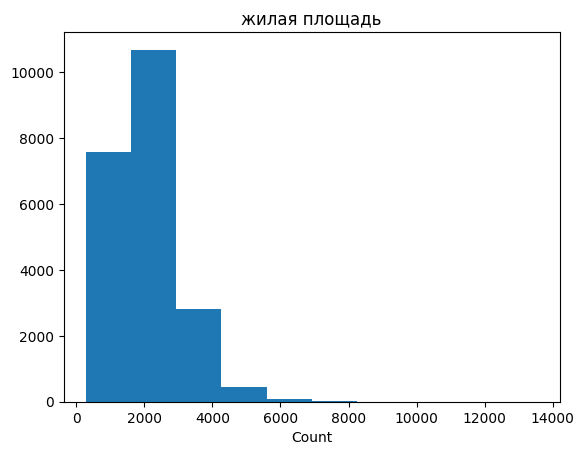

In [31]:
plt.hist(df['sqft_living']);
plt.xlabel('m2')
plt.xlabel('Count')
plt.title('жилая площадь')

In [78]:
f"{round((df['sqft_living'].mean() * 100 / df['sqft_lot'].mean()), 2)} %"

'13.77 %'

Изучите распределение года постройки

In [109]:
dat=df.groupby('yr_built').agg({'price': 'mean'}).sort_values('price')
dat

,price
yr_built,
1943,333373.470588
1944,356322.078571
1942,379290.497758
1969,425408.592857
1961,432213.071429
...,...
1909,696135.159574
2001,741030.796721
1905,752977.986486


In [33]:
data = df['yr_built'].value_counts()
data

yr_built
2014    559
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64

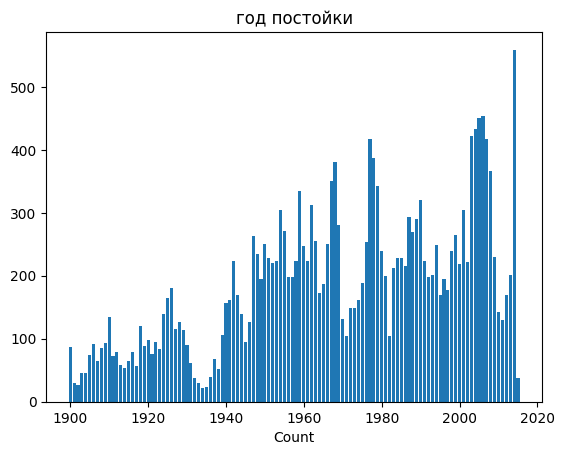

In [37]:
plt.bar(data.index, data.values);
plt.xlabel('year')
plt.xlabel('Count')
plt.title('год постойки');

Самое большоре количество домов постоено в 2014 году


2.1. Изучите распределение домов от наличия вида на набережную
Постройте график
Сделайте выводы

In [96]:
df.groupby('view').agg({'waterfront': 'mean'}).sort_values('waterfront')

,waterfront
view,
0,0.000000
1,0.003012
2,0.008307
3,0.037255
4,0.423197


In [135]:
waterfront= df['waterfront'].value_counts()
waterfront

waterfront
0    21450
1      163
Name: count, dtype: int64

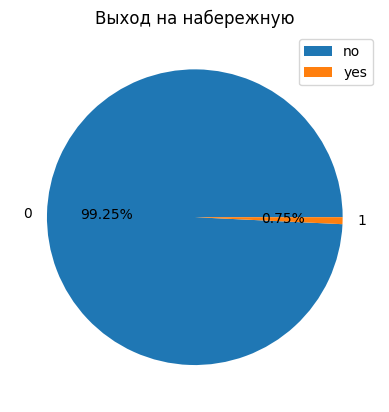

In [137]:

plt.pie (waterfront.values, labels=waterfront.index,autopct='%1.2f%%');
plt.legend(['no', 'yes']);
plt.title('Выход на набережную', fontsize=12);



In [87]:
data = df.groupby('waterfront').agg({'view': 'mean'})
data

,view
waterfront,
0,0.207459
1,3.766871


Большинство зданий не имеют вид на набережную

Изучите распределение этажей домов


In [73]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [75]:
floors=df['floors'].value_counts()
floors

floors
1.0    10680
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5        8
Name: count, dtype: int64

Text(0.5, 1.0, 'этажи')

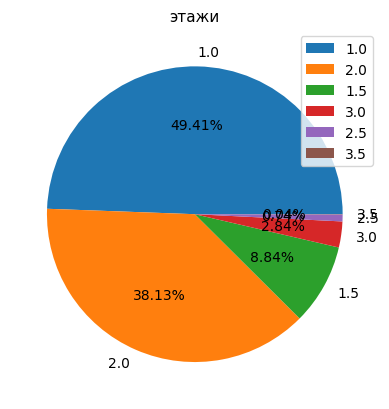

In [83]:

floors=df['floors'].value_counts()
plt.pie (floors.values, labels=floors.index,autopct='%1.2f%%');
plt.legend(floors.index);
plt.title('этажи', fontsize=11)

большинство одножэтажных зданий


Изучите распределение состояния домов


In [11]:
a = df.groupby('yr_renovated').agg({'yr_built': 'mean'}).sort_values('yr_renovated')
a

,yr_built
yr_renovated,
0,1972.395092
1934,1919.000000
1940,1915.000000
1944,1908.000000
1945,1914.000000
...,...
2011,1941.076923
2012,1943.909091
2013,1939.513514


In [8]:
a=df['yr_built'].value_counts()
a

yr_built
2014    559
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64

In [12]:
b=df['yr_renovated'].value_counts()
b

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

In [15]:
con=df['condition'].value_counts()
con

condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64

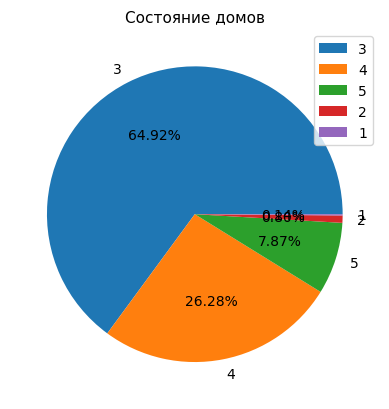

In [18]:

plt.pie (con.values, labels=con.index,autopct='%1.2f%%');
plt.legend(con.index);
plt.title('Состояние домов', fontsize=11);

In [72]:
con2=df.groupby('condition').agg({'yr_built': 'median'}).sort_values('condition')
con2

,yr_built
condition,
1,1928.0
2,1950.0
3,1988.0
4,1962.0
5,1950.0


В большинстве своем состояние домов удовлетворительное (3)

Исследуйте, какие характеристики недвижимости влияют на стоимость недвижимости, с применением не менее 5 диаграмм из урока.
Анализ сделайте в формате storytelling: дополнить каждый график письменными выводами и наблюдениями.


In [73]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [74]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [75]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [76]:
df['price'].mode()

0    350000.0
1    450000.0
Name: price, dtype: float64

In [77]:
df['price'].min(),df['price'].max()

(75000.0, 7700000.0)

In [86]:

sale=df[['price', 'date']].head()
sale


,price,date
0,2014,20141013T000000
1,2014,20141209T000000
2,2015,20150225T000000
3,2014,20141209T000000
4,2015,20150218T000000


In [122]:

bed=df.groupby('bedrooms').agg({'price': 'median'}).sort_values('price')
bed


,price
bedrooms,
0,288000.0
1,299000.0
2,374000.0
3,413000.0
11,520000.0
4,549997.5
5,620000.0
33,640000.0
6,650000.0


In [127]:
df.groupby('bedrooms').agg({'price': 'mean'}).sort_values('price')

,price
bedrooms,
1,3.176429e+05
2,4.013727e+05
0,4.095038e+05
3,4.662321e+05
11,5.200000e+05
4,6.354195e+05
33,6.400000e+05
5,7.865998e+05
10,8.193333e+05


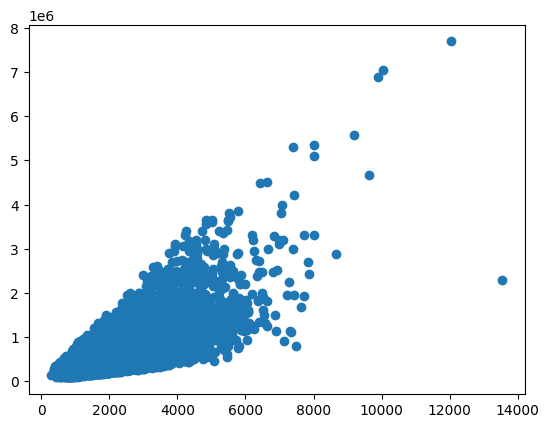

In [144]:
plt.scatter(y=df['price'], x=df['sqft_living'])
plt.show()

На графике показано, чем больше  жилая площадь помещения, тем выше стоимость дома 


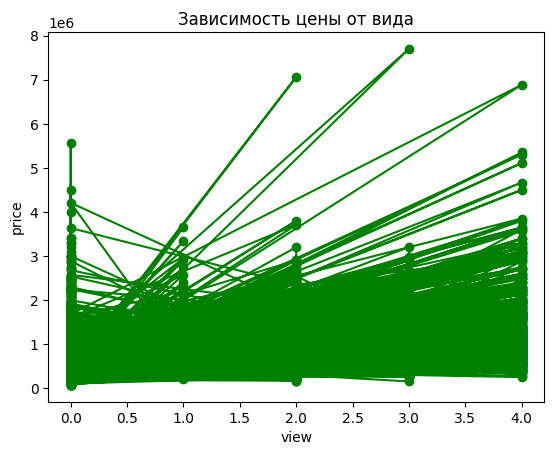

In [204]:
x=df['view']
y=df['price']
plt.plot(x,y, marker="o", c="g");
plt.xlabel('view')
plt.ylabel('price')
plt.title('Зависимость цены от вида');


дома с видом 4 имеют большую стоимость 

In [234]:
kas=df.groupby('grade').agg({'price': 'mean'}).sort_values('grade')
kas

,price
grade,
1,1.420000e+05
3,2.056667e+05
4,2.143810e+05
5,2.485240e+05
6,3.019196e+05
7,4.025903e+05
8,5.428528e+05
9,7.735132e+05
10,1.071771e+06


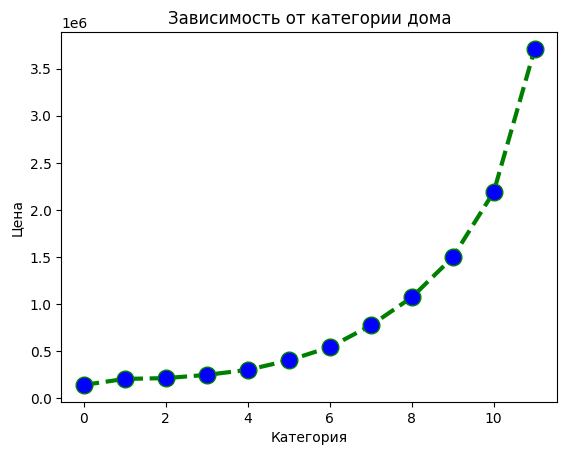

In [233]:
#x=df['grade']
#y=df['price']
kas=df.groupby('grade').agg({'price': 'mean'}).sort_values('grade')
plt.plot(kas.values, color='green', linestyle='dashed', linewidth = 3,
         marker='o', markerfacecolor='blue', markersize=12)
plt.xlabel('Категория')
plt.ylabel('Цена')
plt.title('Зависимость от категории дома');



Чем выше категория дома, тем выше его цена

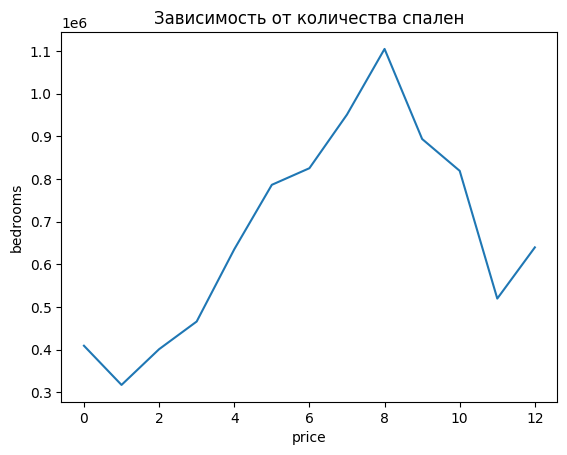

In [238]:
bed=df.groupby('bedrooms').agg({'price': 'mean'}).sort_values('bedrooms')
plt.plot(bed.values);
plt.xlabel('price')
plt.ylabel('bedrooms')
plt.title('Зависимость от количества спален');

In [239]:
bed=df.groupby('bedrooms').agg({'price': 'mean'}).sort_values('bedrooms')
bed

,price
bedrooms,
0,4.095038e+05
1,3.176429e+05
2,4.013727e+05
3,4.662321e+05
4,6.354195e+05
5,7.865998e+05
6,8.255206e+05
7,9.511847e+05
8,1.105077e+06


Наиболее высокая стоимость у домов с 8 спальнями

Text(0.5, 1.0, 'Зависимость от количества этажей')

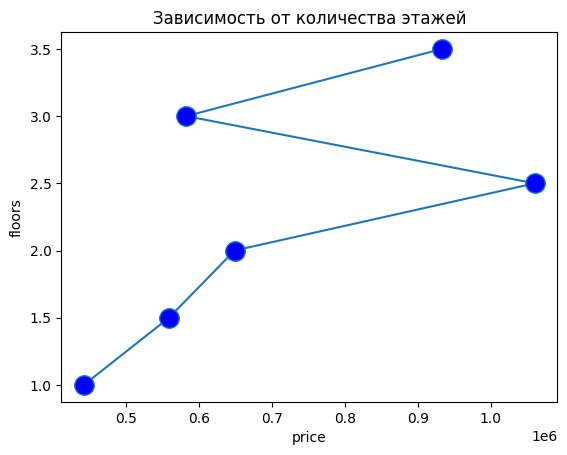

In [77]:
data1=df.groupby('floors').agg({'price': 'mean'}).sort_values('floors').astype(int)
plt.plot(data1.values, data1.index, marker='o', markerfacecolor='blue', markersize=14)
#plt.hist(data1.values, data1.index,range, color = 'green',histtype = 'bar', rwidth = 0.8)
plt.xlabel('price')
plt.ylabel('floors')
plt.title('Зависимость от количества этажей')

Наибольшую стоимость имеют дома с количеством этажей 2,5

In [34]:
data1=df.groupby('floors').agg({'price': 'mean'}).sort_values('floors')
data1

,price
floors,
1.0,4.421806e+05
1.5,5.589806e+05
2.0,6.488912e+05
2.5,1.060346e+06
3.0,5.825260e+05
3.5,9.333125e+05


In [38]:
data=df['floors'].value_counts()
data

floors
1.0    10680
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5        8
Name: count, dtype: int64